In [1]:
# ============================================================
# F3 — Week 05 Bayesian Optimisation Notebook
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# ============================================================

# -----------------------------
# Imports (top of notebook)
# -----------------------------
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.exceptions import ConvergenceWarning

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

In [2]:
# ============================================================
# 0) Config
# ============================================================

# Your expected project paths:
INPUTS_PATH = "data/F3/initial_inputs.npy"
OUTPUTS_PATH = "data/F3/initial_outputs.npy"

# If you're running in an environment where files are uploaded elsewhere
# (e.g., /mnt/data), this fallback helps without changing your structure.
FALLBACK_INPUTS_PATH = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

RANDOM_SEED = 42

# Acquisition settings
XI = 0.005               # EI exploration parameter
DIST_D0 = 0.03           # distance-penalty length scale (domain is [0,1]^3)
N_GLOBAL = 30000         # global random candidates
N_LOCAL = 10000          # local candidates around current best
LOCAL_SIGMA = 0.08       # local perturbation std-dev

# Models
GP_RESTARTS = 8
GP_ALPHA = 1e-6          # nugget for stability

RF_N_ESTIMATORS = 600
RF_MIN_SAMPLES_LEAF = 1

GBM_ENSEMBLE_SIZE = 12
GBM_MAX_DEPTH = 6


# Quiet common GP warnings (kernel bounds etc.)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


def resolve_path(primary: str, fallback: str) -> str:
    """Return primary if exists, else fallback if exists, else primary."""
    if os.path.exists(primary):
        return primary
    if os.path.exists(fallback):
        return fallback
    return primary



In [3]:
# ============================================================
# 1) Load
# ============================================================

inputs_path = resolve_path(INPUTS_PATH, FALLBACK_INPUTS_PATH)
outputs_path = resolve_path(OUTPUTS_PATH, FALLBACK_OUTPUTS_PATH)

X = np.load(inputs_path)   # (n, 3)
y = np.load(outputs_path)  # (n,)

assert X.ndim == 2 and X.shape[1] == 3, f"Expected X shape (n,3), got {X.shape}"
assert y.ndim == 1 and len(y) == len(X), f"Expected y shape (n,), got {y.shape} vs {X.shape}"

n = len(y)
best_idx = int(np.argmax(y))   # we maximise (less negative is better)
x_best = X[best_idx]
y_best = float(y[best_idx])

print(f"Loaded F3 dataset: n={n}, dim=3")
print(f"Current best observed y: {y_best:.6f} at x={x_best}")



Loaded F3 dataset: n=19, dim=3
Current best observed y: -0.034835 at x=[0.49258141 0.61159319 0.34017639]


In [4]:
# ============================================================
# 2) Surrogate (GP primary + RF/GBM auxiliary)
# ============================================================

# Scale X and y for numerical stability in GP training
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_s = x_scaler.fit_transform(X)
y_s = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

# GP kernel: Constant * Matérn(5/2, ARD) + White noise
kernel = (
    C(1.0, (1e-2, 1e2))
    * Matern(length_scale=np.ones(3), length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=GP_ALPHA,
    normalize_y=False,          # we're already scaling y
    n_restarts_optimizer=GP_RESTARTS,
    random_state=RANDOM_SEED
)
gp.fit(X_s, y_s)

print("\nGP trained.")
print("Learned kernel:", gp.kernel_)

# RF auxiliary
rf = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    random_state=RANDOM_SEED,
    bootstrap=True,
    oob_score=False,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    n_jobs=-1
)
rf.fit(X, y)
print("\nRF trained.")

# GBM ensemble auxiliary
gbm_models = []
for k in range(GBM_ENSEMBLE_SIZE):
    gbm = HistGradientBoostingRegressor(
        random_state=RANDOM_SEED + k,
        max_depth=GBM_MAX_DEPTH,
        learning_rate=0.05,
        max_iter=400
    )
    gbm.fit(X, y)
    gbm_models.append(gbm)
print("GBM ensemble trained.")





GP trained.
Learned kernel: 1.06**2 * Matern(length_scale=[9.89, 10.7, 0.237], nu=2.5) + WhiteKernel(noise_level=0.00967)

RF trained.
GBM ensemble trained.


In [5]:
# ============================================================
# 3) Acquisition (EI + min-distance penalty)
# ============================================================

def gp_predict_y(Xcand: np.ndarray):
    """Predict mean/std in original y-space using GP trained in scaled space."""
    Xc_s = x_scaler.transform(Xcand)
    mu_s, std_s = gp.predict(Xc_s, return_std=True)

    mu = y_scaler.inverse_transform(mu_s.reshape(-1, 1)).ravel()
    std = std_s * y_scaler.scale_[0]  # scale std back to original y units
    return mu, std


def expected_improvement(mu: np.ndarray, std: np.ndarray, best: float, xi: float = 0.0):
    """EI for maximisation."""
    imp = mu - best - xi
    ei = np.zeros_like(mu)

    mask = std > 1e-12
    Z = np.zeros_like(mu)
    Z[mask] = imp[mask] / std[mask]

    ei[mask] = imp[mask] * norm.cdf(Z[mask]) + std[mask] * norm.pdf(Z[mask])
    return np.maximum(ei, 0.0)


def distance_penalty(Xcand: np.ndarray, Xobs: np.ndarray, d0: float = 0.03):
    """
    Smooth penalty: 0 when d=0; tends to 1 as d grows.
    pen = 1 - exp(-(d/d0)^2)
    """
    d = pairwise_distances(Xcand, Xobs).min(axis=1)
    pen = 1.0 - np.exp(- (d / d0) ** 2)
    return pen, d


rng = np.random.default_rng(RANDOM_SEED)

# Global candidates across the full cube
X_global = rng.random((N_GLOBAL, 3))

# Local candidates around current best (exploitation)
X_local = x_best + rng.normal(0.0, LOCAL_SIGMA, size=(N_LOCAL, 3))
X_local = np.clip(X_local, 0.0, 1.0)

X_cand = np.vstack([X_global, X_local])

mu, std = gp_predict_y(X_cand)
ei = expected_improvement(mu, std, best=y_best, xi=XI)

pen, dmin = distance_penalty(X_cand, X, d0=DIST_D0)
score = ei * pen

best_cand_idx = int(np.argmax(score))
x_next = X_cand[best_cand_idx]

print("\nAcquisition completed.")
print(f"Proposed x_next = {x_next}")
print(f"GP predicted mu={mu[best_cand_idx]:.6f}, std={std[best_cand_idx]:.6f}, EI={ei[best_cand_idx]:.6f}")
print(f"Nearest-neighbour distance={dmin[best_cand_idx]:.6f}, penalty={pen[best_cand_idx]:.6f}, score={score[best_cand_idx]:.6f}")




Acquisition completed.
Proposed x_next = [0.98343443 0.91507397 0.39841805]
GP predicted mu=-0.045029, std=0.067993, EI=0.020203
Nearest-neighbour distance=0.177701, penalty=1.000000, score=0.020203


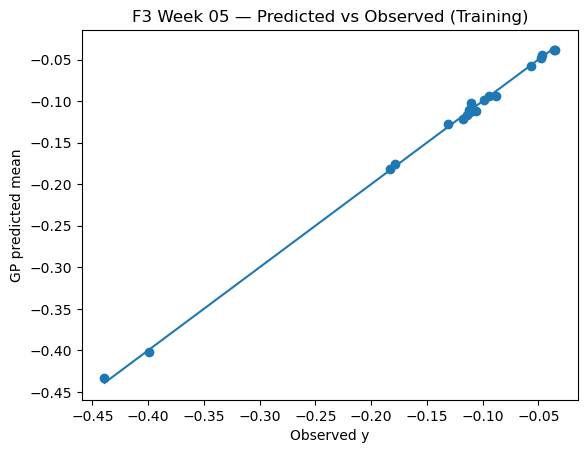

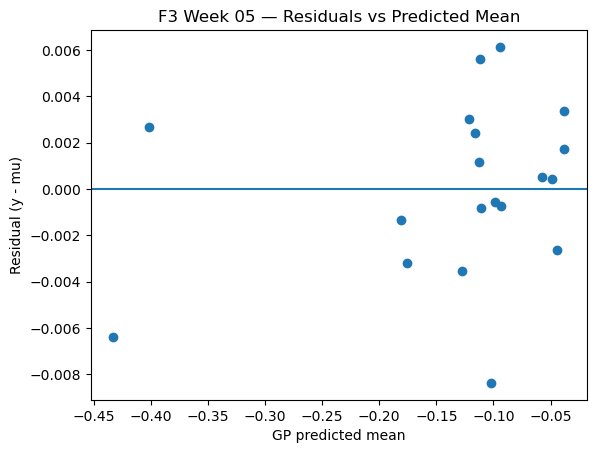

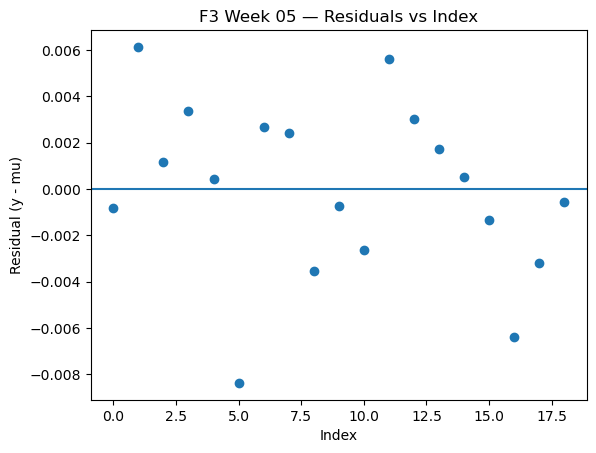

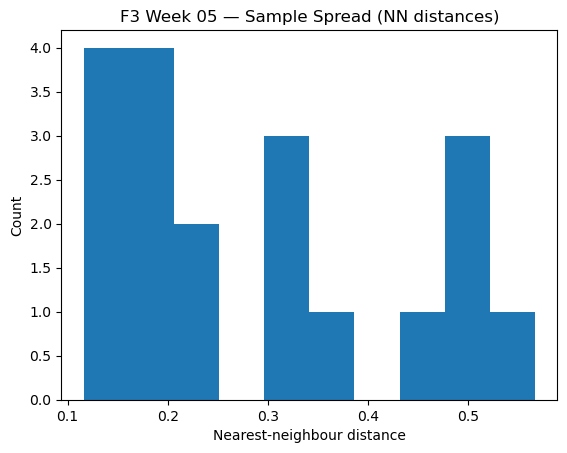


NN distance summary: min=0.1163, median=0.2466, max=0.5666
RF importance x1: 0.0749
RF importance x2: 0.1693
RF importance x3: 0.7558


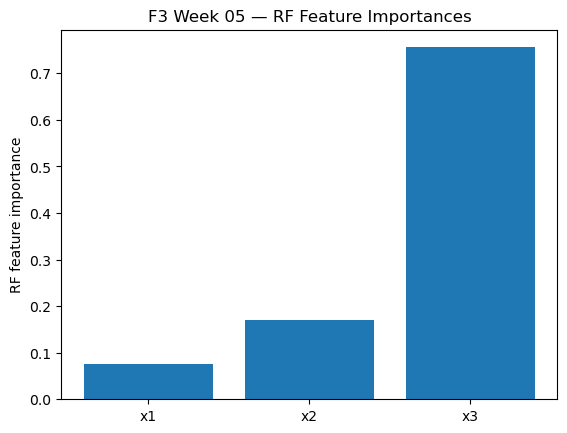


Uncertainty cross-check at x_next:
GP:  mu=-0.045029, std=0.067993
RF:  mu=-0.072477, std=0.050730 (tree spread)
GBM: mu=-0.131937, std=0.000000 (ensemble spread)


In [6]:
# ============================================================
# 4) Diagnostics
# ============================================================

# 4.1 Predicted vs observed (GP on training points)
mu_train, std_train = gp_predict_y(X)

plt.figure()
plt.scatter(y, mu_train)
lo = min(y.min(), mu_train.min())
hi = max(y.max(), mu_train.max())
plt.plot([lo, hi], [lo, hi])
plt.xlabel("Observed y")
plt.ylabel("GP predicted mean")
plt.title("F3 Week 05 — Predicted vs Observed (Training)")
plt.show()

# 4.2 Residuals
resid = y - mu_train

plt.figure()
plt.scatter(mu_train, resid)
plt.axhline(0)
plt.xlabel("GP predicted mean")
plt.ylabel("Residual (y - mu)")
plt.title("F3 Week 05 — Residuals vs Predicted Mean")
plt.show()

plt.figure()
plt.plot(resid, marker="o", linestyle="none")
plt.axhline(0)
plt.xlabel("Index")
plt.ylabel("Residual (y - mu)")
plt.title("F3 Week 05 — Residuals vs Index")
plt.show()

# 4.3 Nearest-neighbour distance among sampled points (are we collapsing?)
D = pairwise_distances(X, X)
np.fill_diagonal(D, np.inf)
nn_dist = D.min(axis=1)

plt.figure()
plt.hist(nn_dist, bins=10)
plt.xlabel("Nearest-neighbour distance")
plt.ylabel("Count")
plt.title("F3 Week 05 — Sample Spread (NN distances)")
plt.show()

print(f"\nNN distance summary: min={nn_dist.min():.4f}, median={np.median(nn_dist):.4f}, max={nn_dist.max():.4f}")

# 4.4 RF feature importances (rough proxy)
importances = rf.feature_importances_
for j, imp in enumerate(importances):
    print(f"RF importance x{j+1}: {imp:.4f}")

plt.figure()
plt.bar([1, 2, 3], importances)
plt.xticks([1, 2, 3], ["x1", "x2", "x3"])
plt.ylabel("RF feature importance")
plt.title("F3 Week 05 — RF Feature Importances")
plt.show()

# 4.5 Uncertainty cross-check at proposed point (RF/GBM spreads)
# RF tree predictions
rf_tree_preds = np.array([t.predict(x_next.reshape(1, -1))[0] for t in rf.estimators_])
rf_mu, rf_std = float(rf_tree_preds.mean()), float(rf_tree_preds.std())

# GBM ensemble predictions
gbm_preds = np.array([m.predict(x_next.reshape(1, -1))[0] for m in gbm_models])
gbm_mu, gbm_std = float(gbm_preds.mean()), float(gbm_preds.std())

print("\nUncertainty cross-check at x_next:")
print(f"GP:  mu={mu[best_cand_idx]:.6f}, std={std[best_cand_idx]:.6f}")
print(f"RF:  mu={rf_mu:.6f}, std={rf_std:.6f} (tree spread)")
print(f"GBM: mu={gbm_mu:.6f}, std={gbm_std:.6f} (ensemble spread)")


In [7]:
# ============================================================
# 5) Output (one line X for tutor submission)
# ============================================================

# Print in a clean single-line format:
print("\n===== SUBMIT THIS X (one row) =====")
print(f"{x_next[0]:.6f} {x_next[1]:.6f} {x_next[2]:.6f}")

# Optional: save for copy/paste workflows
np.savetxt("f3_week05_next_x.txt", x_next.reshape(1, -1), fmt="%.6f")
print("Saved to f3_week05_next_x.txt")


===== SUBMIT THIS X (one row) =====
0.983434 0.915074 0.398418
Saved to f3_week05_next_x.txt
